<a href="https://colab.research.google.com/github/ICYEZAGATORE/Fine-Tuning-LLM/blob/main/finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q numpy>=2.0 transformers>=4.41 sentence-transformers


In [2]:
!pip install trl \
peft \
accelerate \
datasets \
evaluate \



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [3]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"✅ GPU: {gpu_name}")
    print(f"✅ Total VRAM: {gpu_memory:.2f} GB")
else:
    print("❌ No GPU detected. Please enable GPU runtime.")
    print("Go to: Runtime → Change runtime type → T4 GPU")

✅ GPU: Tesla T4
✅ Total VRAM: 14.56 GB


In [4]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
    GenerationConfig
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer
import evaluate

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ All imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ All imports loaded successfully!
PyTorch version: 2.9.0+cu128


Dataset Loading and Exploaration

In [5]:
!pip install -q huggingface_hub

from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="Amod/mental_health_counseling_conversations",
    filename="combined_dataset.json",
    repo_type="dataset"
)

print(f"✅ File downloaded to: {file_path}")

combined_dataset.json: 0.00B [00:00, ?B/s]

✅ File downloaded to: /root/.cache/huggingface/hub/datasets--Amod--mental_health_counseling_conversations/snapshots/d7e86f0813c5690181b41f97403c3674aa55dcef/combined_dataset.json


In [6]:
import json

raw_data_list = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        raw_data_list.append(json.loads(line))

raw = raw_data_list

print(f"Type          : {type(raw)}")

if isinstance(raw, list):
    print(f"Total records : {len(raw)}")
    print(f"First record  : {raw[0]}")

elif isinstance(raw, dict):
    print(f"Top-level keys: {list(raw.keys())}")
    for key in raw.keys():
        val = raw[key]
        print(f"\nKey '{key}' — type: {type(val)}, length: {len(val) if hasattr(val, '__len__') else 'N/A'}")
        if isinstance(val, list) and len(val) > 0:
            print(f"  First item: {val[0]}")

Type          : <class 'list'>
Total records : 3512
First record  : {'Context': "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", 'Response': "If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief th

Preview examples

In [7]:
print("=" * 70)
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"CONTEXT (Patient):\n{raw[i]['Context']}")
    print(f"\nRESPONSE (Counselor):\n{raw[i]['Response'][:300]}...")
    print("=" * 70)


--- Example 1 ---
CONTEXT (Patient):
I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.
   How can I change my feeling of being worthless to everyone?

RESPONSE (Counselor):
If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and...

--- Example 2 ---
CONTEXT (Patient):
I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.
  

Statistics and null check

In [8]:
df = pd.DataFrame(raw)

print("Null values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

df['context_word_count'] = df['Context'].apply(lambda x: len(str(x).split()))
df['response_word_count'] = df['Response'].apply(lambda x: len(str(x).split()))

print("\nContext word count stats:")
print(df['context_word_count'].describe())
print("\nResponse word count stats:")
print(df['response_word_count'].describe())

Null values per column:
Context     0
Response    0
dtype: int64

Duplicate rows: 760

Context word count stats:
count    3512.000000
mean       55.180809
std        48.275077
min         5.000000
25%        28.000000
50%        46.000000
75%        68.000000
max       526.000000
Name: context_word_count, dtype: float64

Response word count stats:
count    3512.000000
mean      177.001993
std       120.744872
min         0.000000
25%        93.000000
50%       144.000000
75%       221.000000
max       939.000000
Name: response_word_count, dtype: float64


Visualisation

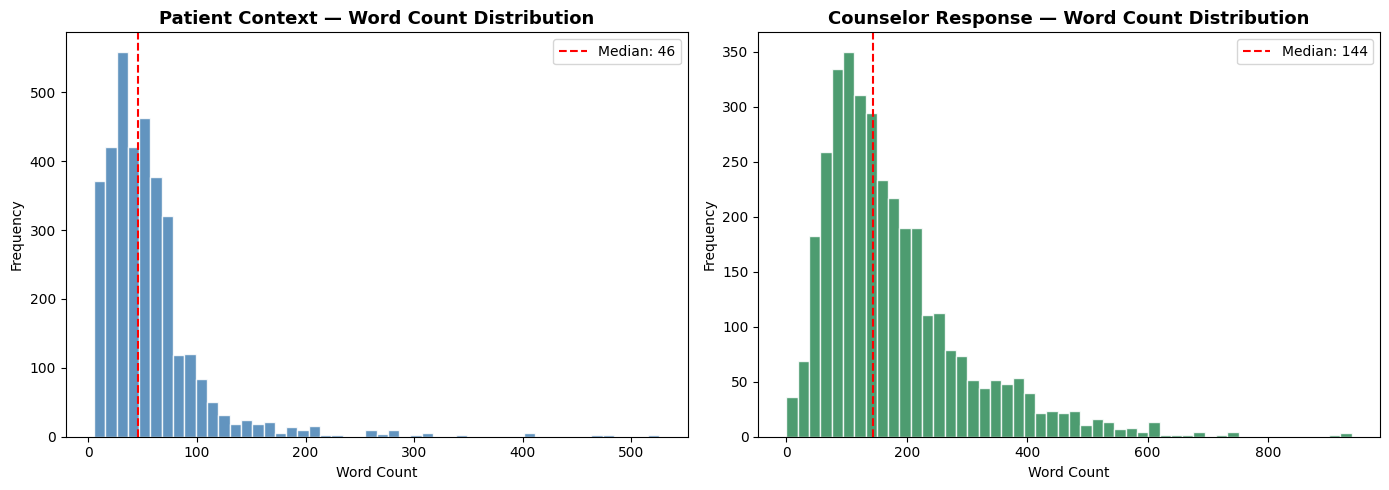

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['context_word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Patient Context — Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['context_word_count'].median(), color='red', linestyle='--',
                label=f'Median: {df["context_word_count"].median():.0f}')
axes[0].legend()

axes[1].hist(df['response_word_count'], bins=50, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Counselor Response — Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['response_word_count'].median(), color='red', linestyle='--',
                label=f'Median: {df["response_word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Data Preprocessing

Clean Text

In [10]:
import re

def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return None
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = text.replace('\xa0', ' ')  # fix non-breaking spaces
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text if len(text) > 10 else None

# Apply cleaning
df['Context_clean']  = df['Context'].apply(clean_text)
df['Response_clean'] = df['Response'].apply(clean_text)

# Step 1 — Drop nulls
df = df.dropna(subset=['Context_clean', 'Response_clean'])
print(f"After dropping nulls        : {len(df)}")

# Step 2 — Drop duplicates on BOTH columns
df = df.drop_duplicates(subset=['Context_clean', 'Response_clean'])
print(f"After dropping duplicates   : {len(df)}")

# Step 3 — Drop empty responses (0 word count)
df['context_wc']  = df['Context_clean'].apply(lambda x: len(x.split()))
df['response_wc'] = df['Response_clean'].apply(lambda x: len(x.split()))

df_filtered = df[
    (df['context_wc']  >= 3)   &
    (df['context_wc']  <= 400) &
    (df['response_wc'] >= 5)   &
    (df['response_wc'] <= 600)
].reset_index(drop=True)

print(f"After length filtering      : {len(df_filtered)}")
print(f"\n✅ Final dataset size        : {len(df_filtered)} examples")
print(f"Context  — mean: {df_filtered['context_wc'].mean():.1f}, max: {df_filtered['context_wc'].max()}")
print(f"Response — mean: {df_filtered['response_wc'].mean():.1f}, max: {df_filtered['response_wc'].max()}")

After dropping nulls        : 3504
After dropping duplicates   : 2023
After length filtering      : 1999

✅ Final dataset size        : 1999 examples
Context  — mean: 52.7, max: 344
Response — mean: 167.6, max: 594


Format Instruction

In [11]:
SYSTEM_PROMPT = (
    "You are a compassionate and professional mental health counselor. "
    "Listen carefully to the patient's concerns and provide empathetic, "
    "supportive, and constructive guidance."
)

def format_instruction(row):
    """
    Format into TinyLlama's ChatML template:
    <|system|> ... </s> <|user|> ... </s> <|assistant|> ... </s>
    """
    return (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{row['Context_clean']}</s>\n"
        f"<|assistant|>\n{row['Response_clean']}</s>"
    )

df_filtered['text'] = df_filtered.apply(format_instruction, axis=1)

print("Sample formatted instruction-response pair:\n")
print(df_filtered['text'].iloc[0])
print(f"\nTotal formatted examples: {len(df_filtered)}")

Sample formatted instruction-response pair:

<|system|>
You are a compassionate and professional mental health counselor. Listen carefully to the patient's concerns and provide empathetic, supportive, and constructive guidance.</s>
<|user|>
I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here. I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it. How can I change my feeling of being worthless to everyone?</s>
<|assistant|>
If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. Maybe read some of the ones

Train/Validation Split

In [12]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_filtered[['text']],
    test_size=0.10,
    random_state=SEED,
    shuffle=True
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

print(f"✅ Train set size      : {len(train_dataset)} examples")
print(f"✅ Validation set size : {len(val_dataset)} examples")

✅ Train set size      : 1799 examples
✅ Validation set size : 200 examples


Model & Tokenizer Loading

In [13]:
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print(f"Model: {MODEL_ID}")
print("Quantization: 4-bit NF4 with double quantization")

Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Quantization: 4-bit NF4 with double quantization


Load Tokenizer

In [14]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"✅ Tokenizer loaded!")
print(f"Vocabulary size : {tokenizer.vocab_size}")
print(f"Max length      : {tokenizer.model_max_length}")
print(f"Pad token       : {tokenizer.pad_token}")

Loading tokenizer...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

✅ Tokenizer loaded!
Vocabulary size : 32000
Max length      : 2048
Pad token       : </s>


Loading the Base model

In [15]:
!pip install -q -U bitsandbytes>=0.46.1

In [16]:
print("Loading base model (this may take 1-2 minutes)...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
base_model.config.use_cache       = False
base_model.config.pretraining_tp  = 1

total_params = sum(p.numel() for p in base_model.parameters())
print(f"\n✅ Base model loaded!")
print(f"Total parameters : {total_params / 1e9:.2f}B")

allocated = torch.cuda.memory_allocated(0) / (1024**3)
reserved  = torch.cuda.memory_reserved(0)  / (1024**3)
print(f"GPU Memory Allocated : {allocated:.2f} GB")
print(f"GPU Memory Reserved  : {reserved:.2f} GB")

Loading base model (this may take 1-2 minutes)...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


✅ Base model loaded!
Total parameters : 0.62B
GPU Memory Allocated : 0.72 GB
GPU Memory Reserved  : 1.84 GB


LoRa PEFT Configuration

In [17]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params       = sum(p.numel() for p in model.parameters())
pct_trainable    = 100 * trainable_params / all_params

print("✅ LoRA applied successfully!")
print(f"Trainable parameters : {trainable_params:,}  ({pct_trainable:.2f}%)")
print(f"Total parameters     : {all_params:,}")
print(f"\n💡 Only training {pct_trainable:.2f}% of parameters — this is the power of LoRA!")

✅ LoRA applied successfully!
Trainable parameters : 12,615,680  (2.01%)
Total parameters     : 628,221,952

💡 Only training 2.01% of parameters — this is the power of LoRA!


Training and Hyperameter Experiments

Experiment tracker

In [18]:
experiment_results = []

def log_experiment(name, lr, batch_size, grad_acc, epochs, lora_r,
                   train_loss, val_loss, train_time_min, gpu_mem_gb, notes=""):
    experiment_results.append({
        "Experiment"       : name,
        "Learning Rate"    : lr,
        "Batch Size"       : batch_size,
        "Grad Accum"       : grad_acc,
        "Epochs"           : epochs,
        "LoRA r"           : lora_r,
        "Train Loss"       : round(train_loss, 4),
        "Val Loss"         : round(val_loss, 4),
        "Train Time (min)" : round(train_time_min, 1),
        "GPU Mem (GB)"     : round(gpu_mem_gb, 2),
        "Notes"            : notes
    })

def print_experiment_table():
    results_df = pd.DataFrame(experiment_results)
    print("\n" + "=" * 100)
    print("HYPERPARAMETER EXPERIMENT RESULTS")
    print("=" * 100)
    print(results_df.to_string(index=False))
    print("=" * 100)
    return results_df

print("✅ Experiment tracker initialized!")

✅ Experiment tracker initialized!


Training function

In [36]:
def run_training_experiment(
    experiment_name, base_model_id, train_data, val_data, tokenizer,
    learning_rate, per_device_batch_size, gradient_accumulation_steps,
    num_train_epochs, lora_r, lora_alpha, output_dir, max_seq_length=512
):
    print(f"\n{'='*60}")
    print(f"Starting: {experiment_name}")
    print(f"  LR={learning_rate}, BS={per_device_batch_size}, GradAcc={gradient_accumulation_steps}")
    print(f"  Epochs={num_train_epochs}, LoRA r={lora_r}")
    print(f"{'='*60}")

    # 4-bit quantization config
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True
    )

    # Load base model
    model = AutoModelForCausalLM.from_pretrained(
        base_model_id,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    model.config.use_cache = False
    model.config.pretraining_tp = 1

    # LoRA config
    lora_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ],
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.CAUSAL_LM
    )
    model = get_peft_model(model, lora_cfg)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_batch_size,
        per_device_eval_batch_size=per_device_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=learning_rate,
        lr_scheduler_type="cosine",
        warmup_steps=10,
        weight_decay=0.01,
        fp16=True,
        logging_steps=50,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        report_to="none",
        seed=SEED
    )

    # ✅ Updated SFTTrainer (modern API)
    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=train_data,
        eval_dataset=val_data,
        processing_class=tokenizer,
        formatting_func=lambda x: x["text"],
        max_seq_length=max_seq_length,
        packing=False
    )

    # Train
    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()

    trainer.train()

    elapsed_min = (time.time() - start_time) / 60
    peak_mem_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

    # Extract losses
    history = trainer.state.log_history
    train_loss = next(
        (entry.get("train_loss") or entry.get("loss")
         for entry in reversed(history)
         if "loss" in entry or "train_loss" in entry),
        0
    )

    eval_results = trainer.evaluate()
    val_loss = eval_results.get("eval_loss", 0)

    print(f"\n✅ {experiment_name} complete!")
    print(f"   Train Loss      : {train_loss:.4f}")
    print(f"   Validation Loss : {val_loss:.4f}")
    print(f"   Training Time   : {elapsed_min:.1f} min")
    print(f"   Peak GPU Memory : {peak_mem_gb:.2f} GB")

    return trainer, train_loss, val_loss, elapsed_min, peak_mem_gb


Experiment 1- Baseline

In [38]:
trainer1, tl1, vl1, time1, mem1 = run_training_experiment(
    experiment_name             = "Exp1_Baseline",
    base_model_id               = MODEL_ID,
    train_data                  = train_dataset,
    val_data                    = val_dataset,
    tokenizer                   = tokenizer,
    learning_rate               = 2e-4,
    per_device_batch_size       = 2,
    gradient_accumulation_steps = 4,
    num_train_epochs            = 1,
    lora_r                      = 16,
    lora_alpha                  = 32,
    output_dir                  = "./exp1_output"
)

log_experiment("Exp1_Baseline", 2e-4, 2, 4, 1, 16,
               tl1, vl1, time1, mem1,
               notes="Baseline — 1 epoch, standard LR")


Starting: Exp1_Baseline
  LR=0.0002, BS=2, GradAcc=4
  Epochs=1, LoRA r=16


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'